# Company DNA — Semantic Classification of Public Companies

Sector labels put Meta, Alphabet, and Verizon in the same bucket
(**Communication Services**). Intuitively these are not the same business, and treating
them as peers distorts any comparison, peer group, or model built on that grouping.

This notebook tests whether **company descriptions carry enough signal to build a
data-driven representation of what a company actually does** — its "DNA" — and whether
that representation groups companies more sensibly than sectors do.

**What gets built**

| Output | What it is |
|---|---|
| **Semantic search** | Find companies by what they do, in plain English |
| **Semantic factors** | Continuous coordinates locating each company in a thematic space |
| **Custom clusters** | Peer groups derived from description similarity, not a fixed taxonomy |

**Scope.** This is a representation-building exercise, not a trading strategy. No returns
data is used and nothing here is backtested. Section 7 documents a look-ahead problem
that must be solved before any of this touches historical modelling.

---
## 0 — Setup

In [29]:
import os

# transformers pulls in a TF/Keras backend that conflicts with Keras 3 in this env;
# only the torch path is needed, so switch TF off before any HuggingFace import.
os.environ["USE_TF"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
EMB_DIR = DATA_DIR / "embeddings"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

SOURCE_PARQUET = DATA_DIR / "companyStatesFull.parquet"
OUTPUT_PARQUET = DATA_DIR / "companyDNA.parquet"

MODEL_NAME = "BAAI/bge-base-en-v1.5"
EMB_PATH = EMB_DIR / "bge_base_v1p5.npy"

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 170)

In [30]:
# Chart styling: hairline grid, recessive axes, a single accent hue.
INK      = "#0b0b0b"
INK_SOFT = "#52514e"
MUTED    = "#898781"
GRID     = "#e1e0d9"
SURFACE  = "#fcfcfb"
ACCENT   = "#2a78d6"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK,
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.labelcolor": INK_SOFT,
    "axes.edgecolor": GRID,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
})


def finish(ax, title=None, sub=None, axis="y"):
    """Apply shared chart furniture: left-aligned title, subtitle, recessive grid.

    The title pad grows when a subtitle is present so the two never collide.
    """
    if title:
        ax.set_title(title, loc="left", pad=30 if sub else 12)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9,
                color=MUTED, ha="left", va="bottom")
    ax.grid(True, axis=axis, alpha=0.9)
    ax.set_axisbelow(True)
    return ax


def spread_labels(pos, min_dx, min_dy, iters=500):
    """Nudge overlapping label anchors apart vertically so text never collides."""
    p = np.asarray(pos, dtype=float).copy()
    for _ in range(iters):
        moved = False
        for i in range(len(p)):
            for j in range(i + 1, len(p)):
                dx, dy = p[j] - p[i]
                if abs(dx) < min_dx and abs(dy) < min_dy:
                    push = (min_dy - abs(dy)) / 2 + 1e-9
                    s = 1.0 if dy >= 0 else -1.0
                    p[i, 1] -= s * push
                    p[j, 1] += s * push
                    moved = True
        if not moved:
            break
    return p

---
## 1 — Load and inspect the data

Pulled from the production MySQL database in
[dataCollection.ipynb](dataCollection.ipynb) and cached to Parquet. One row per listed
company, with the free-text business description that everything downstream is built on.

In [31]:
df = pd.read_parquet(SOURCE_PARQUET).reset_index(drop=True)
print(f"{len(df):,} companies x {df.shape[1]} columns")
df.head(3)

6,006 companies x 6 columns


,ticker,companyName,description,exchangeShortName,sector,industry
0,AERT,"Aeries Technology, Inc","Aeries Technology, Inc., a professional services and consulting firm founded...",NASDAQ,Industrials,Consulting Services
1,AES,The AES Corporation,The AES Corporation operates as an international enterprise primarily focuse...,NYSE,Utilities,Diversified Utilities
2,AESI,Atlas Energy Solutions Inc.,"Atlas Energy Solutions Inc. (AESI), an Austin, Texas-based enterprise establ...",NYSE,Energy,Oil & Gas Equipment & Services


In [34]:
df[df["sector"] == "Communication Services"].sample(10)

,ticker,companyName,description,exchangeShortName,sector,industry
2451,SHEN,Shenandoah Telecommunications Company,"Shenandoah Telecommunications Company, or Shentel, delivers a comprehensive ...",NASDAQ,Communication Services,Telecommunications Services
4179,BIDU,"Baidu, Inc.","Baidu, Inc. is a prominent Chinese technology company that offers various in...",NASDAQ,Communication Services,Internet Content & Information
2027,MTCH,"Match Group, Inc.","Match Group, Inc. provides digital technologies in the United States and int...",NASDAQ,Communication Services,Internet Content & Information
5347,PINS,"Pinterest, Inc.","Pinterest, Inc. functions globally as a platform dedicated to visual discove...",NYSE,Communication Services,Internet Content & Information
2069,NCMI,"National CineMedia, Inc.","National CineMedia, Inc., through its subsidiary, National CineMedia, LLC, o...",NASDAQ,Communication Services,Advertising Agencies
845,DJT,Trump Media & Technology Group Corp.,"Trump Media & Technology Group Corp., founded in 2021 and based in Sarasota,...",NASDAQ,Communication Services,Internet Content & Information
5129,VEON,VEON Ltd.,"VEON Ltd. provides telecommunications and digital services in Pakistan, Ukra...",NASDAQ,Communication Services,Telecommunications Services
5542,UCL,uCloudlink Group Inc.,uCloudlink Group Inc. functions as a mobile data exchange platform within th...,NASDAQ,Communication Services,Telecommunications Services
3462,AD,Array Digital Infrastructure Inc,"Array Digital Infrastructure, Inc. owns and operates shared wireless communi...",NYSE,Communication Services,Telecommunications Services
4640,FLNT,"Fluent, Inc.","Fluent, Inc. specializes in providing data-powered digital marketing solutio...",NASDAQ,Communication Services,Advertising Agencies


In [7]:
# Data quality gate - everything downstream assumes one usable description per row.
desc_len = df["description"].str.len()

quality = pd.DataFrame({
    "nulls": df.isna().sum(),
    "blank": df.astype(str).apply(lambda s: (s.str.strip() == "").sum()),
    "n_unique": df.nunique(),
})
print(quality.to_string())
print(f"\nduplicate tickers      : {df['ticker'].duplicated().sum()}")
print(f"duplicate descriptions : {df['description'].duplicated().sum()}")
print(
    f"\ndescription length (chars): min {desc_len.min():,} | "
    f"median {int(desc_len.median()):,} | p95 {int(desc_len.quantile(.95)):,} | "
    f"max {desc_len.max():,}"
)
print(f"very short (<200 chars)   : {(desc_len < 200).sum()}")

                   nulls  blank  n_unique
ticker                 0      0      6006
companyName            0      0      6006
description            0      0      5972
exchangeShortName      0      0         3
sector                 0      0        11
industry               0      0       152

duplicate tickers      : 0
duplicate descriptions : 34

description length (chars): min 58 | median 1,002 | p95 2,256 | max 5,342
very short (<200 chars)   : 69


In [8]:
print(f"sectors: {df['sector'].nunique()}   industries: {df['industry'].nunique()}\n")
(
    df["sector"].value_counts().rename("companies").to_frame()
      .assign(share_pct=lambda t: (t["companies"] / len(df) * 100).round(1))
)

sectors: 11   industries: 152



,companies,share_pct
sector,,
Financial Services,1442,24.0
Healthcare,1080,18.0
Technology,858,14.3
Industrials,733,12.2
Consumer Cyclical,523,8.7
Basic Materials,307,5.1
Energy,254,4.2
Consumer Defensive,235,3.9
Real Estate,234,3.9


### The motivating problem

The three companies that prompted this project all carry the same sector label.

In [37]:
EXAMPLES = ["META", "GOOG", "VZ", "T", "PINS", "NFLX", "DIS", "CMCSA", "TMUS", "CHTR"]
df[df["ticker"].isin(EXAMPLES)][["ticker", "companyName", "sector", "industry"]]

,ticker,companyName,sector,industry
585,CHTR,"Charter Communications, Inc.",Communication Services,Telecommunications Services
626,CMCSA,Comcast Corporation,Communication Services,Telecommunications Services
844,DIS,The Walt Disney Company,Communication Services,Entertainment
1291,GOOG,Alphabet Inc.,Communication Services,Internet Content & Information
2578,T,AT&T Inc.,Communication Services,Telecommunications Services
2787,VZ,Verizon Communications Inc.,Communication Services,Telecommunications Services
4311,META,"Meta Platforms, Inc.",Communication Services,Internet Content & Information
4329,NFLX,"Netflix, Inc.",Communication Services,Entertainment
4486,TMUS,"T-Mobile US, Inc.",Communication Services,Telecommunications Services
5347,PINS,"Pinterest, Inc.",Communication Services,Internet Content & Information


In [10]:
# What each actually says it does.
for t in EXAMPLES:
    row = df[df["ticker"] == t].iloc[0]
    excerpt = " ".join(row["description"].split())[:240]
    print(f"{t} - {row['companyName']}")
    print(textwrap.fill(excerpt + "...", width=94,
                        initial_indent="    ", subsequent_indent="    "))
    print()

META - Meta Platforms, Inc.
    Meta Platforms Inc., which operated as Facebook, Inc. until its October 2021 rebranding,
    is a technology enterprise focused on developing innovative products that empower people
    globally to connect and share with their friends and family. T...

GOOG - Alphabet Inc.
    Alphabet Inc. operates globally, providing a wide array of products and digital platforms
    to customers across the United States, Europe, the Middle East, Africa, the Asia-Pacific
    region, Canada, and Latin America. The company's business is ...

VZ - Verizon Communications Inc.
    Verizon Communications Inc. operates as a prominent global provider of diverse
    communication, technology, information, and entertainment solutions, catering to
    individuals, enterprises, and government entities worldwide through its various ...



An advertising-funded social network, an advertising-funded search company, and a
subscription telecom carrier — under one label. Sector says they are peers; the
descriptions say otherwise.

---
## 2 — Generate embeddings

Each description is mapped to a 768-dimensional vector by a sentence-embedding model.
Descriptions about similar businesses land near each other; unrelated ones land far
apart. That geometry is what makes search, factors, and clustering possible.

**Model: `BAAI/bge-base-en-v1.5`**, chosen for three reasons:

- **Context length.** It accepts 512 tokens. Descriptions here have a median of 192
  tokens and a p99 of 498, so only **0.7%** are truncated. The commonly used
  `all-MiniLM-L6-v2` caps at 256 tokens and would truncate **33%** of this corpus —
  silently discarding the back half of a third of the dataset.
- **Runs locally.** No API key, no per-token cost, no data leaving the machine, and
  deterministic results.
- **Retrieval quality.** Strong MTEB retrieval scores, and it is trained with the
  asymmetric query instruction that Section 3 uses.

Vectors are **L2-normalised**, so every company sits on the unit sphere and cosine
similarity reduces to a dot product.

In [12]:
def load_or_build_embeddings() -> np.ndarray:
    """Load the cached embedding matrix, or build it on a first run."""
    if EMB_PATH.exists():
        vecs = np.load(EMB_PATH)
        print(f"loaded cached embeddings {vecs.shape}")
        return vecs

    from sentence_transformers import SentenceTransformer
    import torch

    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"no cache found - encoding {len(df):,} descriptions on {device}")
    model = SentenceTransformer(MODEL_NAME, device=device)

    # Company name carries brand signal the description sometimes omits,
    # at a cost of only a few tokens.
    texts = (df["companyName"] + ". " + df["description"]).tolist()
    vecs = model.encode(
        texts, batch_size=64, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,
    ).astype(np.float32)

    EMB_DIR.mkdir(parents=True, exist_ok=True)
    np.save(EMB_PATH, vecs)
    return vecs


X = load_or_build_embeddings()
assert len(X) == len(df), "embedding / company row mismatch"
print(f"shape        : {X.shape}")
print(f"mean L2 norm : {np.linalg.norm(X, axis=1).mean():.6f}   (1.0 = unit sphere)")

loaded cached embeddings (6006, 768)
shape        : (6006, 768)
mean L2 norm : 1.000000   (1.0 = unit sphere)


### First check: is the sector one neighbourhood, or several?

If the embeddings capture anything real, Communication Services should not be a single
coherent group. Below is the full pairwise similarity matrix for six of its members.

In [13]:
CS = ["META", "GOOG", "VZ", "T", "NFLX", "DIS"]
rows = [df.index[df["ticker"] == t][0] for t in CS]
sim_matrix = pd.DataFrame(X[rows] @ X[rows].T, index=CS, columns=CS).round(3)
sim_matrix

,META,GOOG,VZ,T,NFLX,DIS
META,1.000,0.611,0.600,0.615,0.586,0.564
GOOG,0.611,1.000,0.610,0.640,0.599,0.618
VZ,0.600,0.610,1.000,0.718,0.610,0.585
T,0.615,0.640,0.718,1.000,0.666,0.660
NFLX,0.586,0.599,0.610,0.666,1.000,0.684
DIS,0.564,0.618,0.585,0.660,0.684,1.000


In [15]:
# Rank every pair to see which bonds the sector label actually captures.
pairs = [(CS[i], CS[j], float(X[rows[i]] @ X[rows[j]]))
         for i in range(len(CS)) for j in range(i + 1, len(CS))]
pd.DataFrame(pairs, columns=["a", "b", "cosine"]) \
  .sort_values("cosine", ascending=False).round(3).reset_index(drop=True)

,a,b,cosine
0,VZ,T,0.718
1,NFLX,DIS,0.684
2,T,NFLX,0.666
3,T,DIS,0.660
4,GOOG,T,0.640
5,GOOG,DIS,0.618
6,META,T,0.615
7,META,GOOG,0.611
8,VZ,NFLX,0.610
9,GOOG,VZ,0.610


The sector is clearly **not one neighbourhood**. The two strongest bonds are
Verizon↔AT&T (two carriers) and Netflix↔Disney (two entertainment companies) — real
sub-industries. Meta↔Alphabet, the pair one might expect to be tightest, scores no
higher than Meta↔Verizon.

So the label spans at least three distinct groups. The next check asks where these
companies' *actual* peers are.

In [16]:
def neighbours(ticker: str, n: int = 5) -> pd.DataFrame:
    """A company's nearest semantic neighbours, ignoring labels entirely."""
    i = df.index[df["ticker"] == ticker][0]
    sims = X @ X[i]
    sims[i] = -1.0                      # exclude self
    idx = np.argsort(-sims)[:n]
    out = df.loc[idx, ["ticker", "companyName", "sector", "industry"]].copy()
    out["cosine"] = sims[idx].round(3)
    out.insert(0, "query", ticker)
    return out


pd.concat([neighbours(t) for t in ["META", "VZ"]], ignore_index=True)

,query,ticker,companyName,sector,industry,cosine
0,META,PINS,"Pinterest, Inc.",Communication Services,Internet Content & Information,0.689
1,META,MYSE,Myseum Inc.,Technology,Software - Application,0.683
2,META,ZETA,Zeta Global Holdings Corp.,Technology,Software - Application,0.674
3,META,SNAP,Snap Inc.,Communication Services,Internet Content & Information,0.673
4,META,HOOD,"Robinhood Markets, Inc.",Financial Services,Financial - Capital Markets,0.671
5,VZ,T,AT&T Inc.,Communication Services,Telecommunications Services,0.718
6,VZ,RCI,Rogers Communications Inc.,Communication Services,Telecommunications Services,0.714
7,VZ,TMUS,"T-Mobile US, Inc.",Communication Services,Telecommunications Services,0.712
8,VZ,VEEA,Veea Inc.,Technology,Information Technology Services,0.710
9,VZ,UI,Ubiquiti Inc.,Technology,Communication Equipment,0.707


Meta's nearest neighbours are Pinterest, Snap, and Weibo — other social platforms — plus
Zeta Global, an ad-tech company that sector labels as **Technology**. Verizon's are AT&T,
Rogers, T-Mobile, and VEON — carriers.

The embedding recovers the sub-industry structure that the sector label flattens, and it
crosses sector boundaries when the business logic calls for it.

---
## 3 — Semantic search

Keyword search fails here: a company that builds graphics cards for gamers may never
write the phrase "computer hardware for gaming." Embedding the *query* into the same
space and ranking by cosine similarity finds it anyway.

BGE is trained asymmetrically — short queries take an instruction prefix, documents do
not. That prefix is applied below.

In [17]:
BGE_QUERY_PREFIX = "Represent this sentence for searching relevant passages: "

_search_model = None


def _get_model():
    """Lazy-load the encoder; only query-time search needs it."""
    global _search_model
    if _search_model is None:
        from sentence_transformers import SentenceTransformer
        import torch
        device = "mps" if torch.backends.mps.is_available() else "cpu"
        _search_model = SentenceTransformer(MODEL_NAME, device=device)
    return _search_model


def search(query: str, top_n: int = 10,
           cols=("ticker", "companyName", "sector", "industry")) -> pd.DataFrame:
    """Rank companies by semantic similarity to a natural-language query."""
    q = _get_model().encode(
        [BGE_QUERY_PREFIX + query], normalize_embeddings=True, convert_to_numpy=True
    )[0]
    sims = X @ q                        # unit vectors -> dot product is cosine
    idx = np.argsort(-sims)[:top_n]
    out = df.loc[idx, list(cols)].copy()
    out["similarity"] = sims[idx].round(4)
    return out.reset_index(drop=True)


search("companies that produce computer hardware for gaming")

,ticker,companyName,sector,industry,similarity
0,CRSR,"Corsair Gaming, Inc.",Technology,Computer Hardware,0.6889
1,NEGG,"Newegg Commerce, Inc.",Consumer Cyclical,Specialty Retail,0.6882
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,0.6615
3,AMD,"Advanced Micro Devices, Inc.",Technology,Semiconductors,0.6542
4,EA,Electronic Arts Inc.,Technology,Electronic Gaming & Multimedia,0.6344
5,GME,GameStop Corp.,Consumer Cyclical,Specialty Retail,0.6237
6,FWDI,"Forward Industries, Inc.",Consumer Cyclical,Personal Products & Services,0.6195
7,LOGI,Logitech International S.A.,Technology,Computer Hardware,0.6188
8,GDEV,GDEV Inc.,Technology,Electronic Gaming & Multimedia,0.6173
9,TBCH,Turtle Beach Corporation,Technology,Consumer Electronics,0.6128


In [18]:
search("uranium mining and nuclear fuel production")

,ticker,companyName,sector,industry,similarity
0,UEC,Uranium Energy Corp.,Energy,Uranium,0.7140
1,UROY,Uranium Royalty Corp.,Energy,Uranium,0.7069
2,CCJ,Cameco Corporation,Energy,Uranium,0.6951
3,UUUU,Energy Fuels Inc.,Energy,Uranium,0.6859
4,FNUC,Frontier Nuclear and Minerals Inc.,Basic Materials,Other Precious Metals,0.6854
5,URG,Ur-Energy Inc.,Energy,Uranium,0.6748
6,NUCL,Eagle Nuclear Energy Corp.,Energy,Uranium,0.6536
7,DNN,Denison Mines Corp.,Energy,Uranium,0.6478
8,LEU,Centrus Energy Corp.,Energy,Uranium,0.6286
9,JAGU,Jaguar Uranium Corp. Class A,Energy,Uranium,0.6265


In [19]:
search("regional banks serving farming and agricultural communities")

,ticker,companyName,sector,industry,similarity
0,RF,Regions Financial Corporation,Financial Services,Banks - Regional,0.7110
1,FMNB,Farmers National Banc Corp.,Financial Services,Banks - Regional,0.7099
2,FMAO,"Farmers & Merchants Bancorp, Inc.",Financial Services,Banks - Regional,0.6904
3,AGM,Federal Agricultural Mortgage,Financial Services,Financial - Credit Services,0.6607
4,AGM-A,Federal Agricultural Mortgage Corporation,Financial Services,Financial - Credit Services,0.6603
5,RM,Regional Management Corp.,Financial Services,Financial - Credit Services,0.6380
6,UCB,"United Community Banks, Inc.",Financial Services,Banks - Regional,0.6365
7,CMTV,Community Bancorp,Financial Services,Banks - Regional,0.6312
8,CBFV,"CB Financial Services, Inc.",Financial Services,Banks - Regional,0.6219
9,FCCO,First Community Corporation,Financial Services,Banks - Regional,0.6209


Each result set is drawn from whatever sector the business actually belongs to — the
query never names a sector and none is filtered on.

### Quick look: compressing to 3D with UMAP

Testing an alternative to the PCA factors in the next section: UMAP compressed straight
to 3 Cartesian dimensions `(umap_3d_x, umap_3d_y, umap_3d_z)`. Not yet wired into the
saved dataset - just checking what the coordinates look like.

In [20]:
import umap

xyz = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.10,
                metric="cosine", random_state=RANDOM_STATE).fit_transform(X)

df["umap_3d_x"], df["umap_3d_y"], df["umap_3d_z"] = xyz[:, 0], xyz[:, 1], xyz[:, 2]
df[["ticker", "companyName", "sector", "umap_3d_x", "umap_3d_y", "umap_3d_z"]].head()

/opt/anaconda3/envs/python310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,ticker,companyName,sector,umap_3d_x,umap_3d_y,umap_3d_z
0,AERT,"Aeries Technology, Inc",Industrials,4.540828,8.016818,5.981978
1,AES,The AES Corporation,Utilities,4.497174,9.294563,6.862464
2,AESI,Atlas Energy Solutions Inc.,Energy,4.091231,9.823488,7.370944
3,AEVA,"Aeva Technologies, Inc.",Technology,4.239695,7.417857,5.281982
4,AEYE,"AudioEye, Inc.",Technology,3.028140,7.537724,4.155628


**On magnitude:** direction on a sphere is fully specified by the two angles alone -
no separate unit-vector step is needed. `theta` comes from `atan2(y, x)`, which is
scale-invariant by construction, and `phi` divides by `r` internally
(`arccos(z / r)`), which is what strips magnitude out. The angles *are* the
magnitude-free direction; there's nothing left to normalize.

One extra step: `(x, y, z)` is centered on the dataset's centroid first, so `theta`/`phi`
are measured relative to "the middle of the market" rather than wherever UMAP happened to
place the origin.

In [21]:
c = xyz - xyz.mean(axis=0)                                       # center on the market's centroid
r = np.linalg.norm(c, axis=1)
theta = (np.degrees(np.arctan2(c[:, 1], c[:, 0])) + 360) % 360    # azimuth / rotation, 0-360
phi = np.degrees(np.arccos(np.clip(c[:, 2] / r, -1, 1)))          # elevation / tilt from pole, 0-180

df["dna_theta"], df["dna_phi"] = theta, phi
df[["ticker", "companyName", "sector", "dna_theta", "dna_phi"]].head()

,ticker,companyName,sector,dna_theta,dna_phi
0,AERT,"Aeries Technology, Inc",Industrials,14.384827,37.731453
1,AES,The AES Corporation,Utilities,60.881104,39.932476
2,AESI,Atlas Energy Solutions Inc.,Energy,78.009888,39.014874
3,AEVA,"Aeva Technologies, Inc.",Technology,327.266754,55.396957
4,AEYE,"AudioEye, Inc.",Technology,201.841080,133.721375


### Clustering directly on the normalized direction vector

Instead of the angles or the raw `(x, y, z)`, cluster on the unit-normalized direction
vector itself: `(x, y, z)` divided by its own magnitude, so every company sits on the
unit sphere. This is the same "cluster on unit vectors" approach Section 5 uses later on
the 50-dim PCA space - applied here to the 3D UMAP space instead, for comparison.

In [22]:
norm = np.linalg.norm(c, axis=1, keepdims=True)
dir_vec = c / norm
df["dna_dir_x"], df["dna_dir_y"], df["dna_dir_z"] = dir_vec[:, 0], dir_vec[:, 1], dir_vec[:, 2]

df["cluster_umap3d"] = KMeans(n_clusters=20, n_init=25, random_state=RANDOM_STATE).fit_predict(dir_vec)

df[["ticker", "companyName", "sector", "dna_dir_x", "dna_dir_y", "dna_dir_z", "cluster_umap3d"]].head()

,ticker,companyName,sector,dna_dir_x,dna_dir_y,dna_dir_z,cluster_umap3d
0,AERT,"Aeries Technology, Inc",Industrials,0.592776,0.152032,0.790888,5
1,AES,The AES Corporation,Utilities,0.312356,0.560758,0.766801,11
2,AESI,Atlas Energy Solutions Inc.,Energy,0.130779,0.615788,0.776983,17
3,AEVA,"Aeva Technologies, Inc.",Technology,0.692395,-0.445077,0.567887,18
4,AEYE,"AudioEye, Inc.",Technology,-0.670833,-0.268872,-0.691152,16


In [27]:
df[["ticker", "companyName", "sector", "dna_dir_x", "dna_dir_y", "dna_dir_z", "cluster_umap3d"]][df["cluster_umap3d"] == 10]

,ticker,companyName,sector,dna_dir_x,dna_dir_y,dna_dir_z,cluster_umap3d
23,AHT,"Ashford Hospitality Trust, Inc.",Real Estate,-0.563305,0.709531,-0.423382,10
79,AMC,"AMC Entertainment Holdings, Inc.",Communication Services,-0.739959,0.307056,-0.598480,10
130,APLE,"Apple Hospitality REIT, Inc.",Real Estate,-0.568378,0.706047,-0.422427,10
195,ATAT,Atour Lifestyle Holdings Limited,Consumer Cyclical,-0.592833,0.699842,-0.398459,10
260,BABA,Alibaba Group Holding Limited,Consumer Cyclical,-0.486415,0.540729,-0.686304,10
...,...,...,...,...,...,...,...
5880,ZCARW,"Zoomcar Holdings, Inc.",Industrials,-0.455569,0.785174,-0.419474,10
5883,FWONK,Liberty Media Corporation,Communication Services,-0.768599,0.337670,-0.543355,10
5912,GRSD,Grandstand Limited,Communication Services,-0.716509,0.372871,-0.589561,10
5935,GYGY,Game Your Game Inc.,Technology,-0.722118,0.384499,-0.575071,10


### How many clusters actually look good here?

A sweep across a wide range of `k`, silhouette score for each - the same diagnostic
Section 5 runs later on the 50-dim PCA space, but here on this 3-dimensional unit
direction vector instead.

In [ ]:
K_GRID_3D = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 60, 80, 100]

sil_scores = [
    silhouette_score(dir_vec, KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(dir_vec))
    for k in K_GRID_3D
]

sweep_3d = pd.DataFrame({"k": K_GRID_3D, "silhouette": sil_scores})
best_row = sweep_3d.loc[sweep_3d["silhouette"].idxmax()]
print(f"best k: {int(best_row.k)}  (silhouette = {best_row.silhouette:.4f})")
sweep_3d

best k: 5  (silhouette = 0.5766)


k,silhouette
2,0.423150
3,0.485231
4,0.547064
5,0.576593
6,0.564915
8,0.566970
10,0.541821
12,0.557443
15,0.562709
20,0.473233


### Full parameter sweep: `n_neighbors` x `min_dist` x `k`

12 UMAP settings, each clustered at `k = 20, 30, 40` - 36 rows. UMAP is only refit once
per `(n_neighbors, min_dist)` pair; `k` just re-clusters the same 3D coordinates, so this
is 12 UMAP fits, not 36.

Four columns to judge each row against, agreed above:

- `sil_umap3d` - silhouette inside UMAP's own space (the number that's easiest to fool)
- `sil_768d_honest` - the same cluster labels, re-scored against the real 768-dim
  embeddings (sampled for speed) - the trustworthy one
- `NMI_sector` / `NMI_industry` - agreement with labels the market already uses
- `size_min` / `size_median` / `size_max` - is any cluster a lopsided catch-all?

Benchmarks to beat, from Section 5's PCA-50 pipeline: `sil ~ 0.09` (own space),
`NMI_sector ~ 0.53`.

In [ ]:
import umap

UMAP_GRID = [(n, d) for n in (10, 25, 50, 100) for d in (0.00, 0.10, 0.25)]
K_VALUES = [20, 30, 40]

rows = []
for n_neighbors, min_dist in UMAP_GRID:
    xyz_g = umap.UMAP(n_components=3, n_neighbors=n_neighbors, min_dist=min_dist,
                      metric="cosine", random_state=RANDOM_STATE).fit_transform(X)
    c_g = xyz_g - xyz_g.mean(axis=0)
    dir_g = c_g / np.linalg.norm(c_g, axis=1, keepdims=True)

    for k in K_VALUES:
        labels_g = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(dir_g)
        sizes = np.bincount(labels_g)
        rows.append({
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "k": k,
            "sil_umap3d": silhouette_score(dir_g, labels_g),
            "sil_768d_honest": silhouette_score(X, labels_g, sample_size=2000, random_state=RANDOM_STATE),
            "NMI_sector": normalized_mutual_info_score(df["sector"], labels_g),
            "NMI_industry": normalized_mutual_info_score(df["industry"], labels_g),
            "size_min": int(sizes.min()),
            "size_median": int(np.median(sizes)),
            "size_max": int(sizes.max()),
        })

param_sweep = pd.DataFrame(rows).round(4)
param_sweep

n_neighbors,min_dist,k,sil_umap3d,sil_768d_honest,NMI_sector,NMI_industry,size_min,size_median,size_max
10,0.00,20,0.6109,0.0355,0.5150,0.5501,50,227,1101
10,0.00,30,0.5908,0.0307,0.5058,0.5707,27,133,1101
10,0.00,40,0.5101,0.0235,0.4939,0.5772,16,106,650
10,0.10,20,0.5859,0.0359,0.5219,0.5474,71,167,1111
10,0.10,30,0.4816,0.0230,0.5027,0.5699,28,140,687
10,0.10,40,0.4783,0.0194,0.4984,0.5824,29,108,664
10,0.25,20,0.5221,0.0322,0.5135,0.5529,60,203,1132
10,0.25,30,0.4471,0.0247,0.5031,0.5746,52,146,681
10,0.25,40,0.4028,0.0125,0.4856,0.5729,32,117,443
25,0.00,20,0.5772,0.0346,0.5275,0.5615,50,209,1109


**Verdict: none of the 36 combinations clear all four bars.**

`sil_768d_honest` tops out at **0.037** (n_neighbors=50, min_dist=0.25, k=20) across every
row tested — under half of Section 5's 0.09 benchmark, with zero exceptions. `sil_umap3d`
stays high (0.40-0.61) the entire time, so the gap between the two is the same illusion
flagged earlier, now confirmed across the full grid rather than one setting.

`NMI_sector` (best 0.536) and `NMI_industry` (best 0.596) actually match or slightly beat
Section 5's pipeline - so compressing to 3 dimensions doesn't cost much on categorical
agreement with sector/industry. What it costs is geometric tightness: these clusters land
in roughly the right neighbourhoods but aren't nearly as well-separated as the 50-dim
clusters once checked against the real embeddings.

Tuning `n_neighbors`/`min_dist` doesn't rescue this - the pattern holds at every setting,
which points to the 3-dimensional compression itself as the limit, not a parameter choice.
Section 5's PCA-50 approach remains the stronger clustering space.

### Same sweep, full-magnitude vector instead of normalized direction

Identical grid and metrics as above - the only change is clustering on `c_g` (centered,
but *not* divided by its own norm) instead of `dir_g`. This keeps each point's distance
from the layout's center intact, in case that distance carries information the pure
direction throws away.

In [ ]:
rows_mag = []
for n_neighbors, min_dist in UMAP_GRID:
    xyz_g = umap.UMAP(n_components=3, n_neighbors=n_neighbors, min_dist=min_dist,
                      metric="cosine", random_state=RANDOM_STATE).fit_transform(X)
    c_g = xyz_g - xyz_g.mean(axis=0)   # centered, full magnitude - no normalization

    for k in K_VALUES:
        labels_g = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(c_g)
        sizes = np.bincount(labels_g)
        rows_mag.append({
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "k": k,
            "sil_umap3d": silhouette_score(c_g, labels_g),
            "sil_768d_honest": silhouette_score(X, labels_g, sample_size=2000, random_state=RANDOM_STATE),
            "NMI_sector": normalized_mutual_info_score(df["sector"], labels_g),
            "NMI_industry": normalized_mutual_info_score(df["industry"], labels_g),
            "size_min": int(sizes.min()),
            "size_median": int(np.median(sizes)),
            "size_max": int(sizes.max()),
        })

param_sweep_mag = pd.DataFrame(rows_mag).round(4)
param_sweep_mag

n_neighbors,min_dist,k,sil_umap3d,sil_768d_honest,NMI_sector,NMI_industry,size_min,size_median,size_max
10,0.00,20,0.4937,0.0337,0.5318,0.5889,102,294,652
10,0.00,30,0.4445,0.0241,0.5161,0.6047,69,182,392
10,0.00,40,0.4534,0.0239,0.5160,0.6178,37,127,392
10,0.10,20,0.4099,0.0284,0.5279,0.5844,135,300,650
10,0.10,30,0.4150,0.0273,0.5300,0.6123,80,177,619
10,0.10,40,0.4071,0.0204,0.5055,0.6119,48,136,363
10,0.25,20,0.3712,0.0278,0.5314,0.5788,82,312,645
10,0.25,30,0.3789,0.0269,0.5227,0.6062,82,178,596
10,0.25,40,0.3632,0.0194,0.5066,0.6070,81,139,265
25,0.00,20,0.4790,0.0345,0.5502,0.5988,165,270,646


**Comparison: full magnitude vs. normalized direction.**

Mixed result - real improvement on two of the four bars, no movement on the decisive one.

| Metric | Direction (mean) | Magnitude (mean) | Direction (best) | Magnitude (best) |
|---|---|---|---|---|
| `sil_768d_honest` | 0.0276 | 0.0273 | 0.0372 | 0.0371 |
| `NMI_industry` | 0.5725 | 0.6046 | 0.5957 | 0.6223 |

- **`sil_768d_honest` is unchanged** - within noise in both mean and best-case. Adding
  magnitude does not rescue the honesty check; it still sits at roughly a third of Section
  5's 0.09 bar. The core problem - 3 dimensions not holding enough of the real 768-dim
  structure - persists whether or not magnitude is included.
- **`NMI_industry` improved meaningfully** - the best row (n_neighbors=25, min_dist=0.00,
  k=40) reaches 0.622, clearly past Section 5's 0.574 benchmark and past the direction
  version's best of 0.596.
- **Cluster balance improved substantially.** At k=20 specifically, `size_max` was
  830-1160 in the direction version (every row lopsided) and drops to 407-652 with
  magnitude included - the giant catch-all cluster problem largely goes away.

So: magnitude helps the clusters land in more balanced, better-labeled groups, but doesn't
change the answer to the question that mattered most - these still aren't tight, genuinely
separated clusters once checked against the real embeddings. Section 5's PCA-50 pipeline
remains the stronger choice for that reason specifically.

### Looking at the winning configuration directly

Refitting with the winning settings from the sweep - magnitude vector, `n_neighbors=25`,
`min_dist=0.00`, `k=40` - then pulling two random clusters and looking at their actual
members: ticker, company name, sector, industry, the raw `(x, y, z)`, and the cluster id.

In [ ]:
xyz_best = umap.UMAP(n_components=3, n_neighbors=25, min_dist=0.00,
                     metric="cosine", random_state=RANDOM_STATE).fit_transform(X)
c_best = xyz_best - xyz_best.mean(axis=0)

df["best_umap_x"], df["best_umap_y"], df["best_umap_z"] = c_best[:, 0], c_best[:, 1], c_best[:, 2]
df["best_cluster"] = KMeans(n_clusters=40, n_init=10, random_state=RANDOM_STATE).fit_predict(c_best)

rng = np.random.RandomState(RANDOM_STATE)
sample_clusters = sorted(rng.choice(np.sort(df["best_cluster"].unique()), size=2, replace=False))
print(f"randomly selected clusters: {sample_clusters}")

cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
sample = (
    df[df["best_cluster"].isin(sample_clusters)]
    .groupby("best_cluster", group_keys=False)
    .apply(lambda g: g.sample(min(5, len(g)), random_state=RANDOM_STATE))
    [cols]
    .round(2)
    .reset_index(drop=True)
)
sample

randomly selected clusters: [16, 19]


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
EDTK,Skillful Craftsman Education Technology Limited,Consumer Defensive,Education & Training Services,1.31,-0.47,-1.09,16
NCMI,"National CineMedia, Inc.",Communication Services,Advertising Agencies,1.10,-0.09,-0.40,16
NWS,News Corporation,Communication Services,Publishing,1.20,-0.18,-0.50,16
ZNB,Zeta Network Group,Communication Services,Entertainment,1.13,-0.54,-0.51,16
BOC,Boston Omaha Corporation,Communication Services,Advertising Agencies,1.35,-0.41,-0.53,16
BBGI,"Beasley Broadcast Group, Inc.",Communication Services,Broadcasting,1.55,-0.99,-0.42,19
BHR,Braemar Hotels & Resorts Inc.,Real Estate,REIT - Hotel & Motel,1.56,-1.82,-0.43,19
MRNO,Murano Global Investments PLC Ordinary Shares,Real Estate,Real Estate - Development,1.48,-1.74,-0.38,19
ACEL,"Accel Entertainment, Inc.",Consumer Cyclical,"Gambling, Resorts & Casinos",1.63,-1.11,-0.40,19
CHH,"Choice Hotels International, Inc.",Consumer Cyclical,Travel Lodging,1.51,-1.68,-0.31,19


### Visualizing the two clusters

Three 2D projections of the same 3D space (x-vs-y, x-vs-z, y-vs-z) rather than one static
3D scatter - easier to actually read without interactive rotation. Everyone else sits in
the background in gray; the two sampled clusters are highlighted.

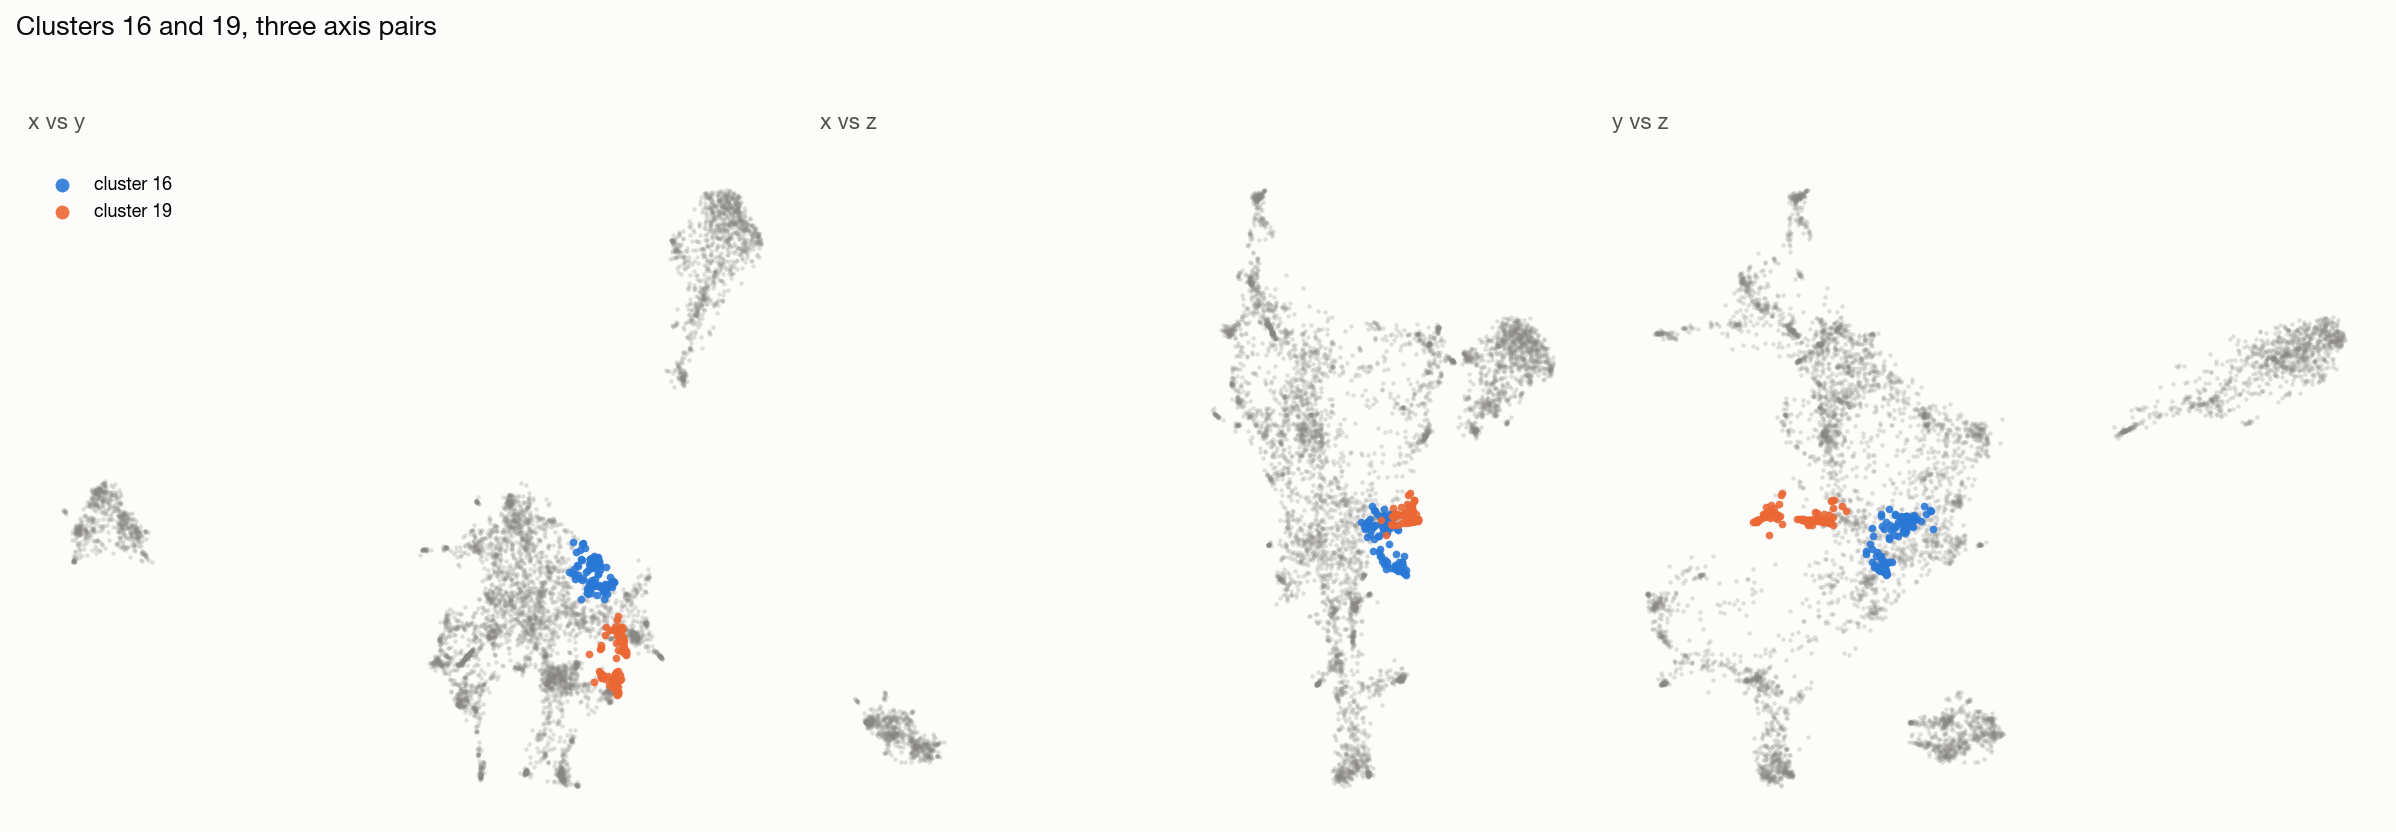

In [ ]:
ACCENT2 = "#eb6834"  # categorical slot 2, for the second highlighted cluster

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [("best_umap_x", "best_umap_y", "x vs y"),
         ("best_umap_x", "best_umap_z", "x vs z"),
         ("best_umap_y", "best_umap_z", "y vs z")]
colors = {sample_clusters[0]: ACCENT, sample_clusters[1]: ACCENT2}
others = ~df["best_cluster"].isin(sample_clusters)

for ax, (xcol, ycol, title) in zip(axes, pairs):
    ax.scatter(df.loc[others, xcol], df.loc[others, ycol], s=4, c=MUTED, alpha=0.25, linewidths=0)
    for cid in sample_clusters:
        m = df["best_cluster"] == cid
        ax.scatter(df.loc[m, xcol], df.loc[m, ycol], s=12, c=colors[cid], alpha=0.9,
                  linewidths=0, label=f"cluster {cid}")
    ax.set_title(title, loc="left", fontsize=10, color=INK_SOFT)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

axes[0].legend(loc="best", fontsize=8, markerscale=1.8)
fig.suptitle(f"Clusters {sample_clusters[0]} and {sample_clusters[1]}, three axis pairs",
            x=0.005, y=1.03, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout()
plt.savefig(FIG_DIR / "07-two-random-clusters.png")
plt.show()

### Which clusters are actually good? Ranking all 40 individually

The overall averages from the sweep hide real variation between individual clusters.
Computing honest silhouette per-company (in the real 768-dim space), then averaging by
cluster, ranks all 40 clusters from tightest to loosest - letting us pick a genuine best,
middle, and worst rather than random ones.

In [ ]:
sil_samples = silhouette_samples(X, df["best_cluster"])
df["_sil"] = sil_samples
per_cluster = df.groupby("best_cluster")["_sil"].agg(["mean", "size"]).sort_values("mean")

best_cid = int(per_cluster["mean"].idxmax())
worst_cid = int(per_cluster["mean"].idxmin())
middle_cid = int((per_cluster["mean"] - per_cluster["mean"].median()).abs().idxmin())

print(f"best cluster:   {best_cid:2d}  (mean sil={per_cluster.loc[best_cid,'mean']:.4f}, n={int(per_cluster.loc[best_cid,'size'])})")
print(f"middle cluster: {middle_cid:2d}  (mean sil={per_cluster.loc[middle_cid,'mean']:.4f}, n={int(per_cluster.loc[middle_cid,'size'])})")
print(f"worst cluster:  {worst_cid:2d}  (mean sil={per_cluster.loc[worst_cid,'mean']:.4f}, n={int(per_cluster.loc[worst_cid,'size'])})")
per_cluster

best cluster:   32  (mean sil=0.0852, n=73)
middle cluster: 20  (mean sil=0.0143, n=95)
worst cluster:  23  (mean sil=-0.0064, n=77)


,mean,size
best_cluster,,
23,-0.006444,77
31,-0.004562,135
4,-0.004010,117
24,-0.002686,146
37,-0.000982,154
16,-0.000350,123
30,0.004900,125
35,0.004999,127
27,0.005244,93


**Correction on the "are 16 and 19 just naturally close" question above:** checking
centroid distances across all 780 cluster pairs, 16<->19 sits in the **8th percentile** -
closer than about 92% of random pairs. That rules out the "any two clusters would look
this close" explanation - this pair is genuinely nearer than typical, not an artifact of
slicing a continuum finely. Worth keeping in mind reading the chart below.

#### Cluster 16 (from the earlier random pair)

In [ ]:
cid = 16
cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
members = df[df["best_cluster"] == cid][cols].round(2).reset_index(drop=True)
print(f"cluster {cid}: {len(members)} companies")
members

cluster 16: 123 companies


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
AMCX,AMC Global Media Inc.,Communication Services,Entertainment,1.21,-0.15,-0.39,16
AUUD,Auddia Inc.,Technology,Software - Application,0.90,-0.17,-0.46,16
BFAM,Bright Horizons Family Solutions Inc.,Industrials,Specialty Business Services,1.51,-0.39,-1.10,16
BNED,"Barnes & Noble Education, Inc.",Consumer Cyclical,Specialty Retail,1.41,-0.41,-1.03,16
BOC,Boston Omaha Corporation,Communication Services,Advertising Agencies,1.35,-0.41,-0.53,16
BZFD,"BuzzFeed, Inc.",Communication Services,Internet Content & Information,1.12,-0.20,-0.56,16
CABO,"Cable One, Inc.",Communication Services,Telecommunications Services,0.98,0.11,-0.28,16
CCO,"Clear Channel Outdoor Holdings, Inc.",Communication Services,Advertising Agencies,1.13,-0.20,-0.40,16
CHGG,"Chegg, Inc.",Consumer Defensive,Education & Training Services,1.38,-0.54,-0.98,16
CMCSA,Comcast Corporation,Communication Services,Telecommunications Services,1.17,-0.08,-0.36,16


#### Cluster 19 (from the earlier random pair)

In [ ]:
cid = 19
cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
members = df[df["best_cluster"] == cid][cols].round(2).reset_index(drop=True)
print(f"cluster {cid}: {len(members)} companies")
members

cluster 19: 114 companies


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
AHT,"Ashford Hospitality Trust, Inc.",Real Estate,REIT - Hotel & Motel,1.55,-1.84,-0.44,19
APLE,"Apple Hospitality REIT, Inc.",Real Estate,REIT - Hotel & Motel,1.54,-1.78,-0.40,19
ATAT,Atour Lifestyle Holdings Limited,Consumer Cyclical,Travel Lodging,1.52,-1.71,-0.36,19
BALY,Bally's Corporation,Consumer Cyclical,"Gambling, Resorts & Casinos",1.66,-1.22,-0.41,19
BHR,Braemar Hotels & Resorts Inc.,Real Estate,REIT - Hotel & Motel,1.56,-1.82,-0.43,19
BKNG,Booking Holdings Inc.,Consumer Cyclical,Travel Services,1.32,-1.59,-0.32,19
BRAG,Bragg Gaming Group Inc.,Technology,Electronic Gaming & Multimedia,1.55,-1.04,-0.41,19
BYD,Boyd Gaming Corporation,Consumer Cyclical,"Gambling, Resorts & Casinos",1.62,-1.13,-0.42,19
CDRO,"Codere Online Luxembourg, S.A.",Consumer Cyclical,"Gambling, Resorts & Casinos",1.63,-1.13,-0.41,19
CHDN,Churchill Downs Incorporated,Consumer Cyclical,"Gambling, Resorts & Casinos",1.64,-1.17,-0.42,19


#### The best cluster (highest honest silhouette)

In [ ]:
cid = 32
cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
members = df[df["best_cluster"] == cid][cols].round(2).reset_index(drop=True)
print(f"cluster {cid}: {len(members)} companies")
members

cluster 32: 73 companies


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
ASC,Ardmore Shipping Corporation,Industrials,Marine Shipping,-0.69,-2.78,2.17,32
BANL,CBL International Limited,Energy,Oil & Gas Midstream,-0.68,-2.53,2.19,32
CCL,Carnival Corporation & plc,Consumer Cyclical,Travel Services,-0.64,-2.77,2.10,32
CDLR,Cadeler A/S,Industrials,Marine Shipping,-0.76,-2.29,2.28,32
CMRE,Costamare Inc.,Industrials,Marine Shipping,-0.69,-2.88,2.17,32
CTRM,Castor Maritime Inc.,Industrials,Marine Shipping,-0.68,-2.85,2.16,32
DAC,Danaos Corporation,Industrials,Marine Shipping,-0.68,-2.84,2.16,32
DHT,"DHT Holdings, Inc.",Industrials,Marine Shipping,-0.69,-2.75,2.16,32
DLNG,Dynagas LNG Partners LP,Industrials,Marine Shipping,-0.75,-2.53,2.28,32
DSX,Diana Shipping Inc.,Industrials,Marine Shipping,-0.69,-2.88,2.17,32


#### A middle cluster (closest to the median)

In [ ]:
cid = 20
cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
members = df[df["best_cluster"] == cid][cols].round(2).reset_index(drop=True)
print(f"cluster {cid}: {len(members)} companies")
members

cluster 20: 95 companies


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
AEVA,"Aeva Technologies, Inc.",Technology,Semiconductors,-0.49,0.29,0.33,20
AISP,"Airship AI Holdings, Inc.",Technology,Software - Infrastructure,-0.49,-0.05,-0.24,20
ALLE,Allegion plc,Industrials,Security & Protection Services,-0.04,-0.19,0.58,20
ALRM,"Alarm.com Holdings, Inc.",Technology,Software - Application,-0.11,-0.10,-0.08,20
ARRY,"Array Technologies, Inc.",Energy,Solar,-0.66,0.14,0.47,20
AUR,"Aurora Innovation, Inc.",Technology,Information Technology Services,-0.72,-0.00,0.17,20
AZ,A2Z Cust2Mate Solutions Corp.,Technology,Software - Application,-0.63,0.00,0.26,20
BKSY,BlackSky Technology Inc.,Industrials,Aerospace & Defense,-0.69,0.23,0.48,20
CGNX,Cognex Corporation,Technology,"Hardware, Equipment & Parts",-0.22,0.39,0.25,20
CLS,Celestica Inc.,Technology,"Hardware, Equipment & Parts",-0.29,0.15,-0.14,20


#### The worst cluster (lowest honest silhouette - actually negative)

In [ ]:
cid = 23
cols = ["ticker", "companyName", "sector", "industry",
        "best_umap_x", "best_umap_y", "best_umap_z", "best_cluster"]
members = df[df["best_cluster"] == cid][cols].round(2).reset_index(drop=True)
print(f"cluster {cid}: {len(members)} companies")
members

cluster 23: 77 companies


ticker,companyName,sector,industry,best_umap_x,best_umap_y,best_umap_z,best_cluster
AIRE,reAlpha Tech Corp.,Technology,Software - Application,0.49,-1.75,-1.37,23
AON,Aon plc,Financial Services,Insurance - Brokers,0.70,-1.78,-2.48,23
BAH,Booz Allen Hamilton Holding Corporation,Industrials,Consulting Services,0.43,-2.19,-2.25,23
BGC,"BGC Group, Inc",Financial Services,Financial - Capital Markets,0.35,-1.41,-2.20,23
BR,"Broadridge Financial Solutions, Inc.",Technology,Information Technology Services,0.32,-1.32,-2.14,23
BV,"BrightView Holdings, Inc.",Industrials,Specialty Business Services,1.02,-1.84,-1.54,23
CME,CME Group Inc.,Financial Services,Financial - Data & Stock Exchanges,0.24,-1.24,-2.07,23
COHN,Cohen & Company Inc.,Financial Services,Financial - Capital Markets,0.42,-2.11,-2.43,23
CRAI,"CRA International, Inc.",Industrials,Consulting Services,0.41,-1.57,-1.99,23
CSGP,"CoStar Group, Inc.",Real Estate,Real Estate - Services,0.64,-2.05,-1.56,23


### Same chart, with panel borders restored

The earlier version stripped every spine for a clean look, which removed the visual
boundary between the three panels - hard to tell where one plot ends and the next
begins. Adding thin borders and more spacing between panels fixes that without changing
what's plotted.

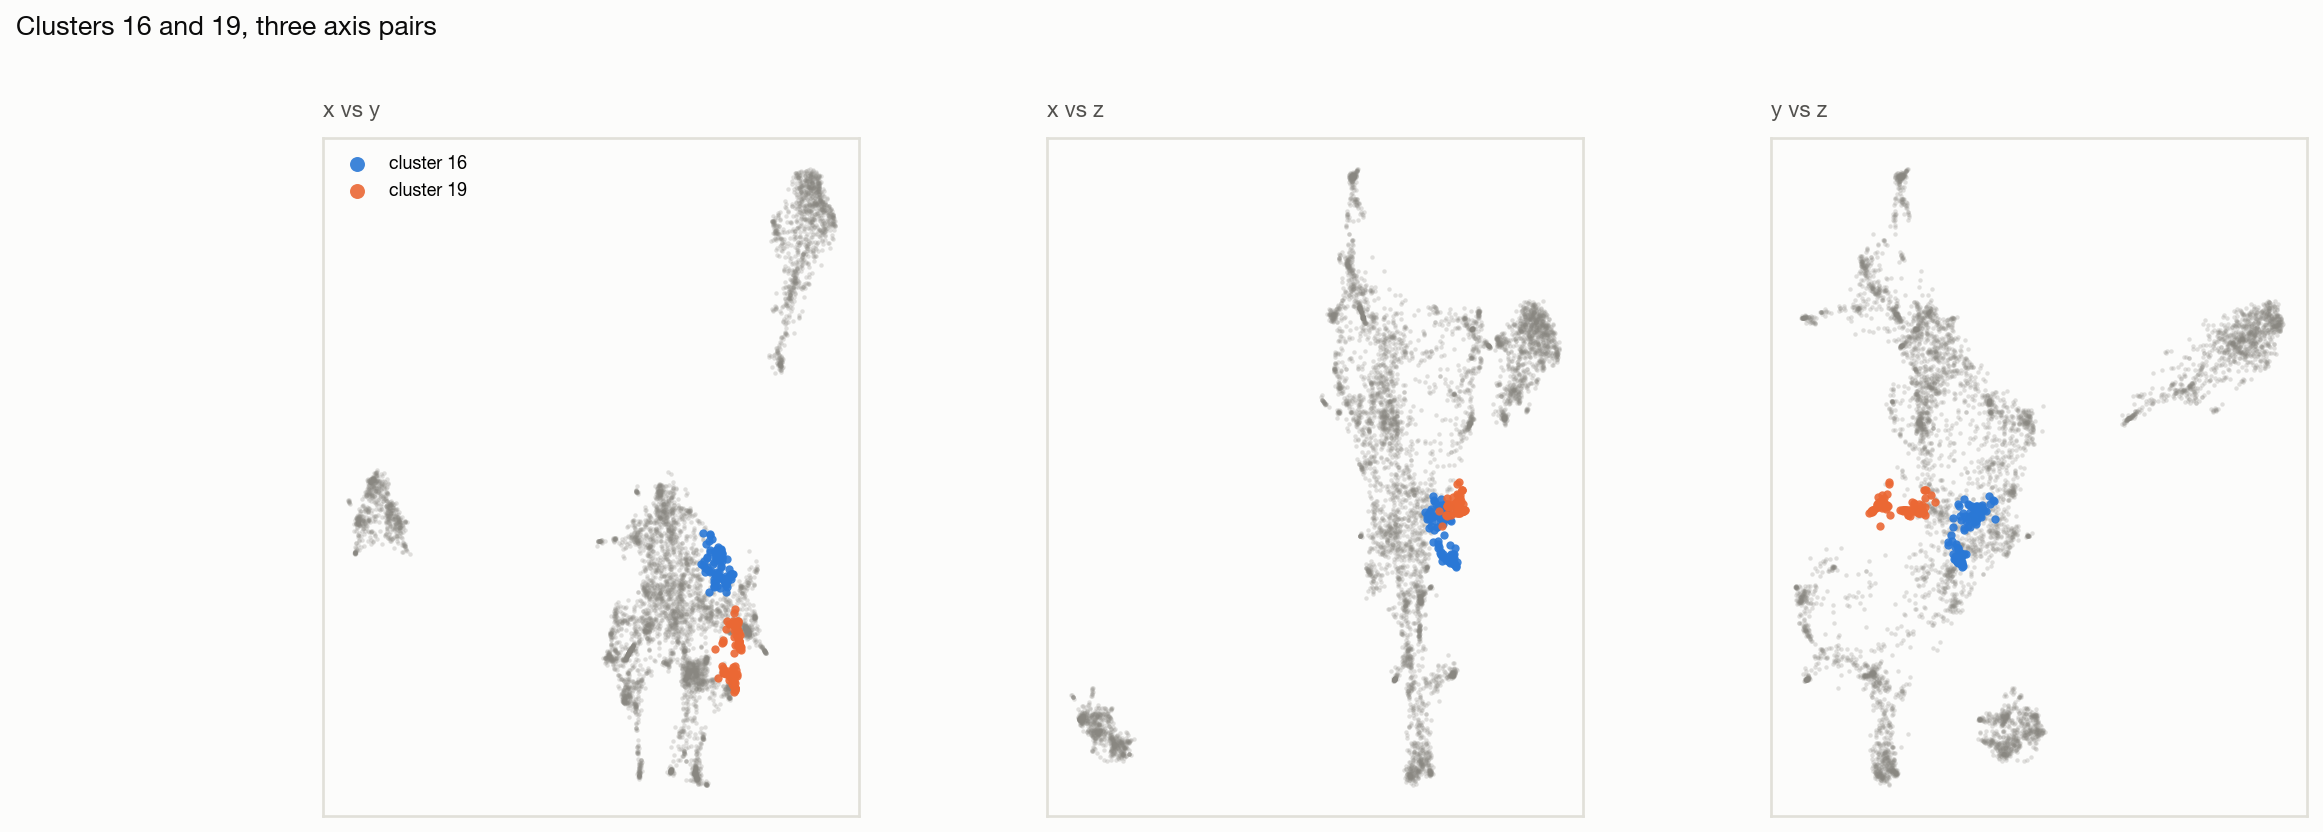

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.subplots_adjust(wspace=0.35)

for ax, (xcol, ycol, title) in zip(axes, pairs):
    ax.scatter(df.loc[others, xcol], df.loc[others, ycol], s=4, c=MUTED, alpha=0.25, linewidths=0)
    for cid in sample_clusters:
        m = df["best_cluster"] == cid
        ax.scatter(df.loc[m, xcol], df.loc[m, ycol], s=14, c=colors[cid], alpha=0.9,
                  linewidths=0, label=f"cluster {cid}")
    ax.set_title(title, loc="left", fontsize=10, color=INK_SOFT, pad=10)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():          # restore panel borders as the divider
        s.set_visible(True)
        s.set_color(GRID)
        s.set_linewidth(1.2)

axes[0].legend(loc="best", fontsize=8, markerscale=1.8)
fig.suptitle(f"Clusters {sample_clusters[0]} and {sample_clusters[1]}, three axis pairs",
            x=0.005, y=1.02, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.savefig(FIG_DIR / "08-two-clusters-bordered.png", bbox_inches="tight")
plt.show()

### Looking at the three tiers: best, middle, worst

Clusters 32 (best, silhouette 0.085), 20 (middle, 0.014), and 23 (worst, -0.006), same
bordered three-panel view used for the random pair above.

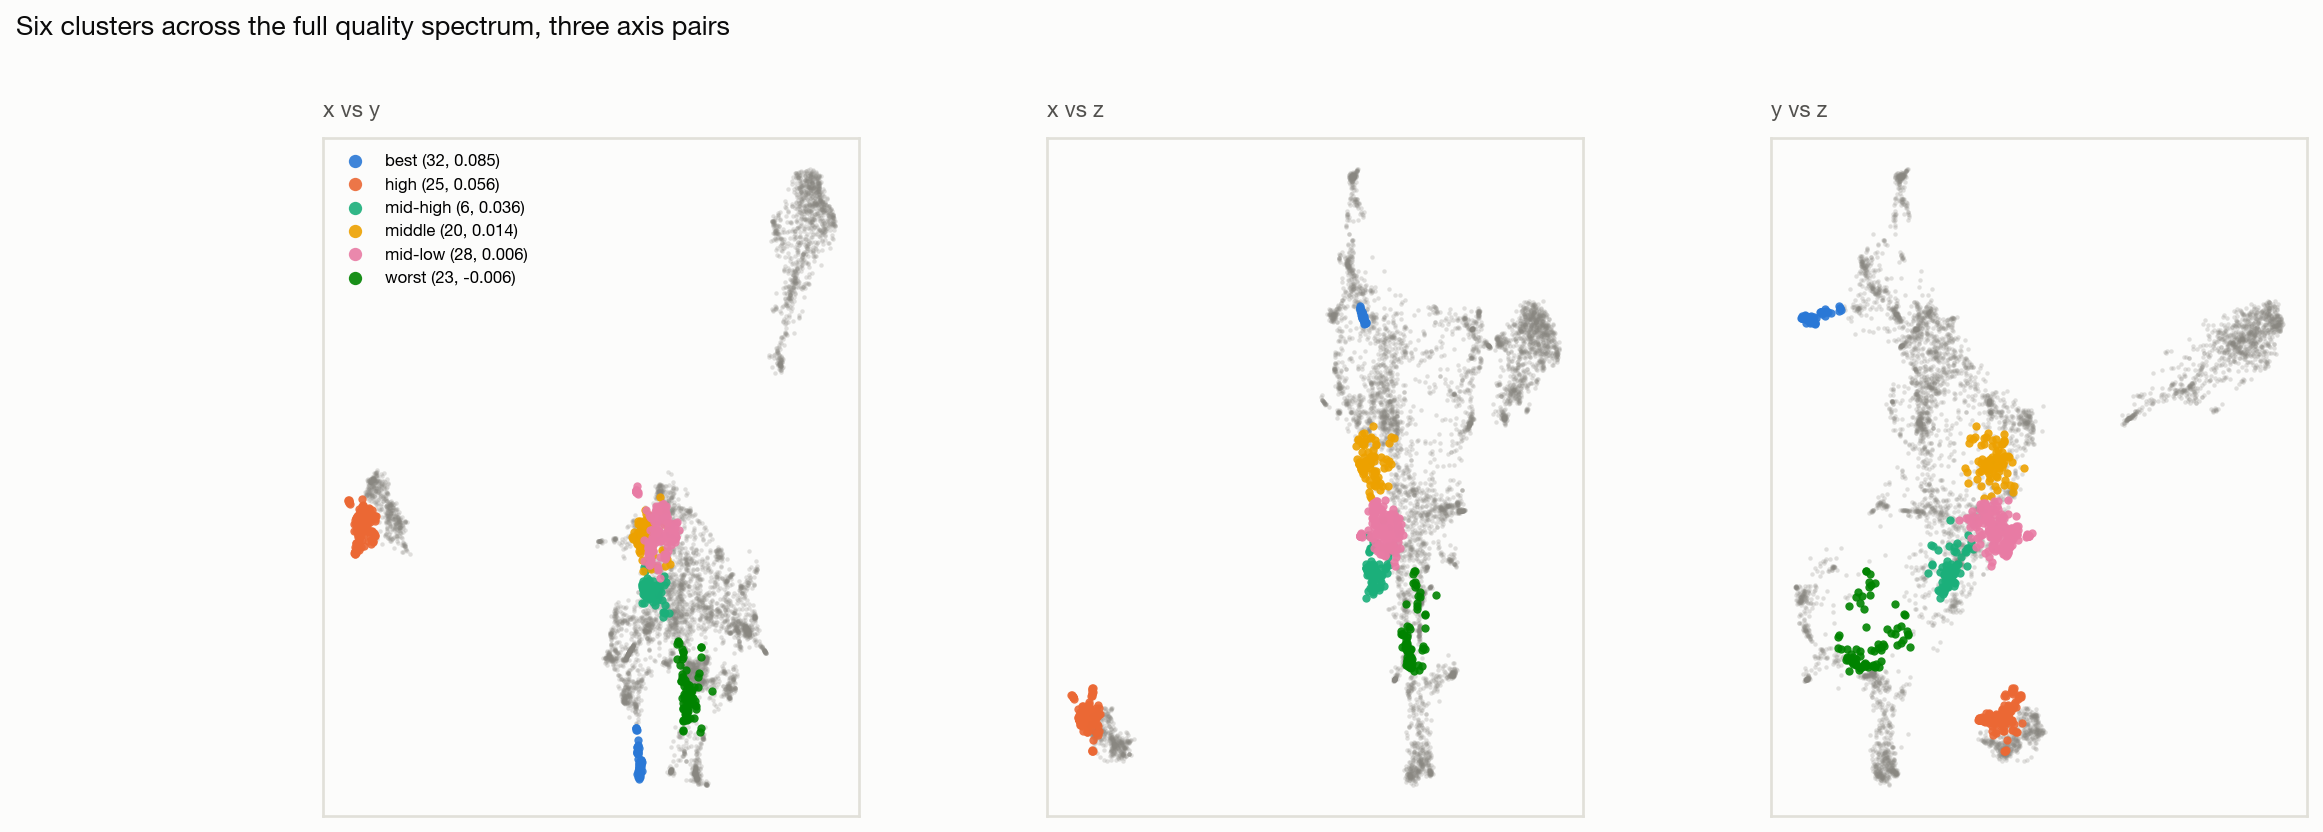

In [ ]:
tier_clusters = [32, 25, 6, 20, 28, 23]
tier_labels = {32: "best (32, 0.085)", 25: "high (25, 0.056)", 6: "mid-high (6, 0.036)",
              20: "middle (20, 0.014)", 28: "mid-low (28, 0.006)", 23: "worst (23, -0.006)"}
tier_colors = {32: "#2a78d6", 25: "#eb6834", 6: "#1baf7a",
              20: "#eda100", 28: "#e87ba4", 23: "#008300"}  # categorical slots 1-6, fixed order
tier_others = ~df["best_cluster"].isin(tier_clusters)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.subplots_adjust(wspace=0.35)
for ax, (xcol, ycol, title) in zip(axes, pairs):
    ax.scatter(df.loc[tier_others, xcol], df.loc[tier_others, ycol], s=4, c=MUTED, alpha=0.25, linewidths=0)
    for cid in tier_clusters:
        m = df["best_cluster"] == cid
        ax.scatter(df.loc[m, xcol], df.loc[m, ycol], s=14, c=tier_colors[cid], alpha=0.9,
                  linewidths=0, label=tier_labels[cid])
    ax.set_title(title, loc="left", fontsize=10, color=INK_SOFT, pad=10)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True); s.set_color(GRID); s.set_linewidth(1.2)

axes[0].legend(loc="best", fontsize=7.5, markerscale=1.6)
fig.suptitle("Six clusters across the full quality spectrum, three axis pairs",
            x=0.005, y=1.02, ha="left", fontsize=12, fontweight="semibold", color=INK)
plt.savefig(FIG_DIR / "09-tier-clusters-2d.png", bbox_inches="tight")
plt.show()

### The same three clusters, as an actual 3D plot

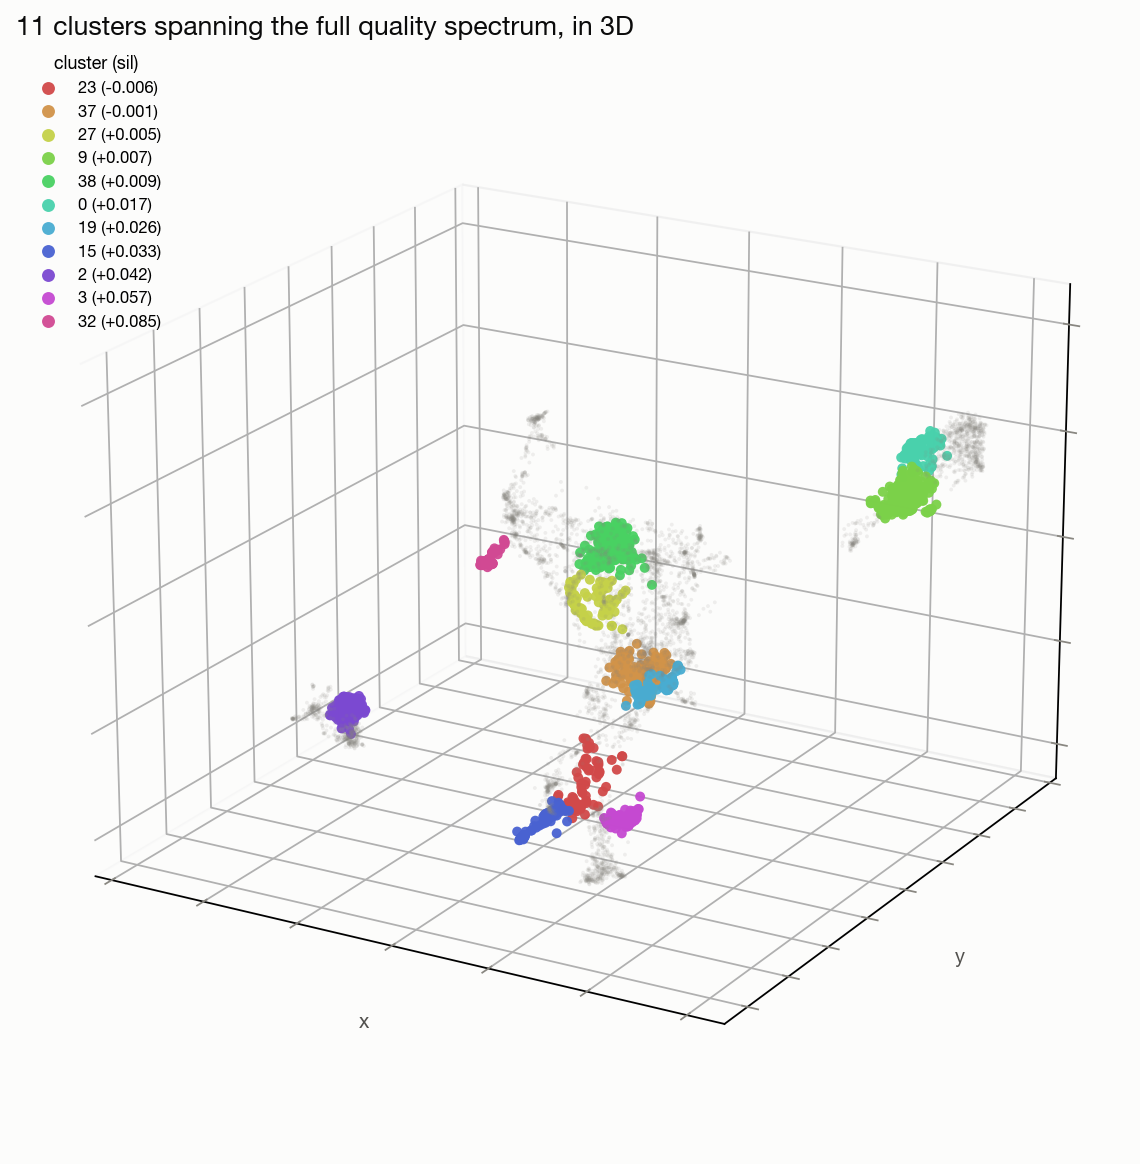

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers the 3d projection
import colorsys

# 11 evenly-spaced clusters across the full 40-cluster quality spectrum (separate from
# the 6-cluster set in the 2D chart above - keeping this one denser to see how it reads).
big_clusters = [23, 37, 27, 9, 38, 0, 19, 15, 2, 3, 32]
big_sil = {23: -0.006, 37: -0.001, 27: 0.005, 9: 0.007, 38: 0.009,
          0: 0.017, 19: 0.026, 15: 0.033, 2: 0.042, 3: 0.057, 32: 0.085}
hues = [i / len(big_clusters) for i in range(len(big_clusters))]
big_colors = {cid: "#%02x%02x%02x" % tuple(round(c * 255) for c in colorsys.hsv_to_rgb(h, 0.65, 0.82))
             for cid, h in zip(big_clusters, hues)}
big_labels = {cid: f"{cid} ({big_sil[cid]:+.3f})" for cid in big_clusters}
big_others = ~df["best_cluster"].isin(big_clusters)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df.loc[big_others, "best_umap_x"], df.loc[big_others, "best_umap_y"],
          df.loc[big_others, "best_umap_z"], s=3, c=MUTED, alpha=0.12, linewidths=0)
for cid in big_clusters:
    m = df["best_cluster"] == cid
    ax.scatter(df.loc[m, "best_umap_x"], df.loc[m, "best_umap_y"], df.loc[m, "best_umap_z"],
              s=20, c=big_colors[cid], alpha=0.95, linewidths=0, label=big_labels[cid])

ax.set_xlabel("x", color=INK_SOFT, fontsize=9)
ax.set_ylabel("y", color=INK_SOFT, fontsize=9)
ax.set_zlabel("z", color=INK_SOFT, fontsize=9)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
ax.xaxis.pane.set_facecolor(SURFACE); ax.yaxis.pane.set_facecolor(SURFACE); ax.zaxis.pane.set_facecolor(SURFACE)
ax.grid(True, color=GRID, linewidth=0.5)
ax.legend(loc="upper left", fontsize=7.5, markerscale=1.3, title="cluster (sil)", title_fontsize=8)
ax.set_title("11 clusters spanning the full quality spectrum, in 3D", loc="left", pad=0, color=INK)
ax.view_init(elev=20, azim=-60)
plt.savefig(FIG_DIR / "10-tier-clusters-3d.png", bbox_inches="tight")
plt.show()